# recursive_opt phases V2 — level-by-level results, limits, and next experiments

This notebook is a **developer/scientist-facing analysis notebook** for the current `recursive_opt` branch.

Goals:

1. **Illustrate results** for each optimization level with **numbers and figures** (initial vs best artifact / config / policy / prior).
2. Make the branch easier to **validate, critique, and improve**.
3. Reuse current example scripts and any previous artifacts if present.
4. Encode the **next practical experiments** as explicit recursive specs rather than prose.

All figures are deliberately simple. The important parts are:
- the **numbers**,
- the **cells to inspect**,
- and the **file/function pointers** that explain how each result is produced.

This notebook assumes you are inside a checkout of `doxav/NewTrace` on branch `recursive_opt`.


## Cell map / execution guide

- **Cells 1–3**: setup, imports, helper functions, optional reuse of previous memory directories.
- **Cells 4–6**: O0/O1 example A — setup/config optimization on bounded real eval-only tasks.
- **Cells 7–9**: O2a example B — code/implementation optimization for concrete components.
- **Cells 10–12**: O0/O1/O2 capability example C — capability optimization under multi-objective tradeoffs.
- **Cells 13–15**: O2/O3 example D — family policy learning and cross-family prior induction.
- **Cell 16**: one summary table of positive / negative claims.
- **Cells 17–19**: next practical recommendation experiments using HF QA + internal multiobjective + one non-QA family.
- **Cell 20**: optional runner template for the recommended experiments.
- **Cell 21**: appendix mapping cells → files/functions to inspect.

If you want only the **current branch evidence**, run through **Cell 16**.
If you want the **next experiments**, continue through **Cell 20**.


In [1]:

# Cell 1 — setup and robust imports

from __future__ import annotations
from pathlib import Path
import importlib.util
import json
import math
import os
import sys
import subprocess
from typing import Any, Dict, List, Tuple

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()

def find_repo_root(start: Path) -> Path:
    cur = start
    for _ in range(6):
        if (cur / "opto" / "features" / "recursive_opt").exists():
            return cur
        cur = cur.parent
    raise RuntimeError("Could not locate repo root containing opto/features/recursive_opt")

REPO_ROOT = find_repo_root(ROOT)
EXAMPLES_DIR = REPO_ROOT / "examples"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

def import_from_path(module_name: str, path: Path):
    spec = importlib.util.spec_from_file_location(module_name, path)
    mod = importlib.util.module_from_spec(spec)
    assert spec.loader is not None
    spec.loader.exec_module(mod)
    return mod

try:
    import examples.recursive_opt_example_A_learn_setup as exA
    import examples.recursive_opt_example_B_improve_component as exB
    import examples.recursive_opt_example_C_learn_capability as exC
    import examples.recursive_opt_example_D_cross_family as exD
except Exception:
    exA = import_from_path("exA", EXAMPLES_DIR / "recursive_opt_example_A_learn_setup.py")
    exB = import_from_path("exB", EXAMPLES_DIR / "recursive_opt_example_B_improve_component.py")
    exC = import_from_path("exC", EXAMPLES_DIR / "recursive_opt_example_C_learn_capability.py")
    exD = import_from_path("exD", EXAMPLES_DIR / "recursive_opt_example_D_cross_family.py")

from opto.features.recursive_opt import (
    RecursiveGuide,
    MemoryLite,
    best_config_from,
    FamilyPolicyLevel,
    PriorInductionLevel,
    make_scored_task_runner,
)
from opto.features.recursive_opt.tracebench import (
    ensure_eval_only_task_adapter,
    configure_tracebench_adapter,
    make_multiobjective_evaluator,
)
from opto.features.recursive_opt.spec import run_spec

guide = RecursiveGuide()

print("Repo root:", REPO_ROOT)
print("Examples dir:", EXAMPLES_DIR)


Repo root: /home/xav/code/Trace
Examples dir: /home/xav/code/Trace/examples


In [2]:

# Cell 2 — optional reuse of previous outputs / memory directories

REUSE_EXISTING_MEMORY = True

KNOWN_MEMORY_DIRS = [
    REPO_ROOT / "mem_A_online_bin_packing_local",
    REPO_ROOT / "mem_A_multi_param",
    REPO_ROOT / "mem_B_batch_design",
    REPO_ROOT / "mem_B_trace_summarizer",
    REPO_ROOT / "mem_C_capability",
    REPO_ROOT / "mem_D",
]

existing_memory_dirs = [p for p in KNOWN_MEMORY_DIRS if p.exists()]
print("Existing memory dirs:", [str(p) for p in existing_memory_dirs])

def memory_summary_if_exists(path: Path):
    if not path.exists():
        return None
    try:
        mem = MemoryLite(root=str(path))
        return mem.summary()
    except Exception as e:
        return {"error": repr(e)}

existing_summaries = {str(p): memory_summary_if_exists(p) for p in existing_memory_dirs}
pd.DataFrame.from_dict(existing_summaries, orient="index")


Existing memory dirs: ['/home/xav/code/Trace/mem_A_multi_param', '/home/xav/code/Trace/mem_C_capability', '/home/xav/code/Trace/mem_D']


,episodes,artifacts,families,priors
/home/xav/code/Trace/mem_A_multi_param,91,0,[internal:multi_param],{'internal:multi_param': 0.0}
/home/xav/code/Trace/mem_C_capability,92,4,[internal:multiobjective_gsm8k],{'internal:multiobjective_gsm8k': 1.2208333333...
/home/xav/code/Trace/mem_D,88,88,"[<holdout>, <multi>]","{'<multi>': 0.25, '<holdout>': 0.0}"


## Current level map (for interpretation)

- **O0**: task-facing artifact / capability / code component  
- **O1**: setup used to optimize O0 (`LevelConfig` / `MetaLevel`)  
- **O2a**: code-level improvement of a component (`CodeArtifactLevel`)  
- **O2b**: family policy learning (`FamilyPolicyLevel`)  
- **O3**: transferable prior induction on held-out families (`PriorInductionLevel`)  
- **O_n**: declarative control plane (`spec.py`, `run_spec`, budgets, prior reuse)

For code:
- `opto/features/recursive_opt/levels.py`
- `opto/features/recursive_opt/spec.py`
- `opto/features/recursive_opt/memory.py`
- `opto/features/recursive_opt/tracebench.py`

For examples:
- `examples/recursive_opt_example_A_learn_setup.py`
- `examples/recursive_opt_example_B_improve_component.py`
- `examples/recursive_opt_example_C_learn_capability.py`
- `examples/recursive_opt_example_D_cross_family.py`


In [3]:

# Cell 3 — helper utilities used by all figures

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True

def show_bar(df: pd.DataFrame, x: str, y: str, hue: str | None = None, title: str = ""):
    ax = plt.gca()
    if hue is None:
        df.plot(kind="bar", x=x, y=y, ax=ax, legend=False)
    else:
        pivot = df.pivot(index=x, columns=hue, values=y)
        pivot.plot(kind="bar", ax=ax)
    ax.set_title(title)
    ax.set_ylabel(y)
    plt.tight_layout()
    return ax

def call_guide(task, out):
    score, feedback = guide(task, out, None)
    return float(score), str(feedback)

def safe_eval_only():
    try:
        ensure_eval_only_task_adapter(require=True)
    except Exception as e:
        print("Eval-only adapter registration warning:", e)

def maybe_configure_d_tracebench():
    try:
        configure_tracebench_adapter(exD.TRACEBENCH, require=True)
    except Exception as e:
        print("Trace-Bench adapter configuration warning:", e)

safe_eval_only()
maybe_configure_d_tracebench()


## Example A — O1 setup search (selection/config surface)

**What it is testing**

- learn the best setup for a family by optimizing:
  - `batch_size`
  - `batch_design`
  - `memory_policy`
  - `trainer`
- on a bounded real eval-only adapter

**Positive claim**
- O1 can clearly separate weak vs strong setup choices.

**Negative claim**
- the current branch still mainly optimizes **selection/config** here; it does not invent new tool/trainer implementations at this level.

See:
- file: `examples/recursive_opt_example_A_learn_setup.py`
- key functions: `build_level`, `run_offline`, `run_live`
- level classes: `LevelConfig`, `MetaLevel`


In [4]:

# Cell 4 — reproduce example A candidate scores (current branch logic)

rows_A = []

for problem in exA.PROBLEMS:
    mem = MemoryLite(root=str(REPO_ROOT / f"mem_A_collect_{problem.split(':')[-1]}"))
    level = exA.build_level(problem, mem)

    # baseline before candidate proposals
    baseline_cfg = best_config_from(level)
    baseline_out = level.forward(problem)
    baseline_score, baseline_fb = call_guide(problem, baseline_out)
    rows_A.append({
        "problem": problem,
        "candidate": "baseline_current_level",
        "trainer": "MinibatchAlgorithm",
        "batch_size": 1,
        "batch_design": "random",
        "memory_policy": "none",
        "score": baseline_score,
        "delta_vs_baseline": 0.0,
    })

    for cand in exA.CANDIDATES:
        level.propose(**cand)
        out = level.forward(problem)
        s, fb = call_guide(problem, out)
        rows_A.append({
            "problem": problem,
            "candidate": f"{cand['trainer']}|bs={cand['batch_size']}|{cand['batch_design']}|{cand['memory_policy']}",
            "trainer": cand["trainer"],
            "batch_size": cand["batch_size"],
            "batch_design": cand["batch_design"],
            "memory_policy": cand["memory_policy"],
            "score": s,
            "delta_vs_baseline": s - baseline_score,
        })

df_A = pd.DataFrame(rows_A)
df_A


Evaluating agent (iteration 0):   0%|          | 0/1 [00:00<?, ?it/s]

Evaluating agent (iteration 0):   0%|          | 0/1 [00:00<?, ?it/s]

Evaluating agent (iteration 0): 100%|██████████| 1/1 [00:00<00:00,  2.30it/s]

Evaluating agent (iteration 0): 100%|██████████| 1/1 [00:00<00:00,  2.30it/s]

[Step 0] Average test score: -2091.8


...

[Step 0] Average test score: -1.0


Evaluating agent (iteration 0):   0%|          | 0/1 [00:00<?, ?it/s]

Evaluating agent (iteration 0): 100%|██████████| 1/1 [00:00<00:00, 7570.95it/s]

[Step 0] Average test score: -1.0


,problem,candidate,trainer,batch_size,batch_design,memory_policy,score,delta_vs_baseline
0,llm4ad:online_bin_packing_local,baseline_current_level,MinibatchAlgorithm,1,random,none,-2.091800e+03,0.0
1,llm4ad:online_bin_packing_local,BeamsearchAlgorithm|bs=4|failure_balanced|typed,BeamsearchAlgorithm,4,failure_balanced,typed,-1.000000e+09,-999997908.2
2,llm4ad:online_bin_packing_local,UCBSearchAlgorithm|bs=8|curriculum|retrieval,UCBSearchAlgorithm,8,curriculum,retrieval,-1.000000e+09,-999997908.2
3,llm4ad:online_bin_packing_local,MinibatchAlgorithm|bs=1|random|none,MinibatchAlgorithm,1,random,none,-2.091800e+03,0.0
4,llm4ad:online_bin_packing_local,PrioritySearch|bs=4|diversity|none,PrioritySearch,4,diversity,none,-1.000000e+09,-999997908.2
5,internal:multi_param,baseline_current_level,MinibatchAlgorithm,1,random,none,-1.000000e+00,0.0
6,internal:multi_param,BeamsearchAlgorithm|bs=4|failure_balanced|typed,BeamsearchAlgorithm,4,failure_balanced,typed,-1.000000e+09,-999999999.0
7,internal:multi_param,UCBSearchAlgorithm|bs=8|curriculum|retrieval,UCBSearchAlgorithm,8,curriculum,retrieval,-1.000000e+09,-999999999.0
8,internal:multi_param,MinibatchAlgorithm|bs=1|random|none,MinibatchAlgorithm,1,random,none,-1.000000e+00,0.0
9,internal:multi_param,PrioritySearch|bs=4|diversity|none,PrioritySearch,4,diversity,none,-1.000000e+09,-999999999.0


/tmp/ipykernel_556431/1053525446.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


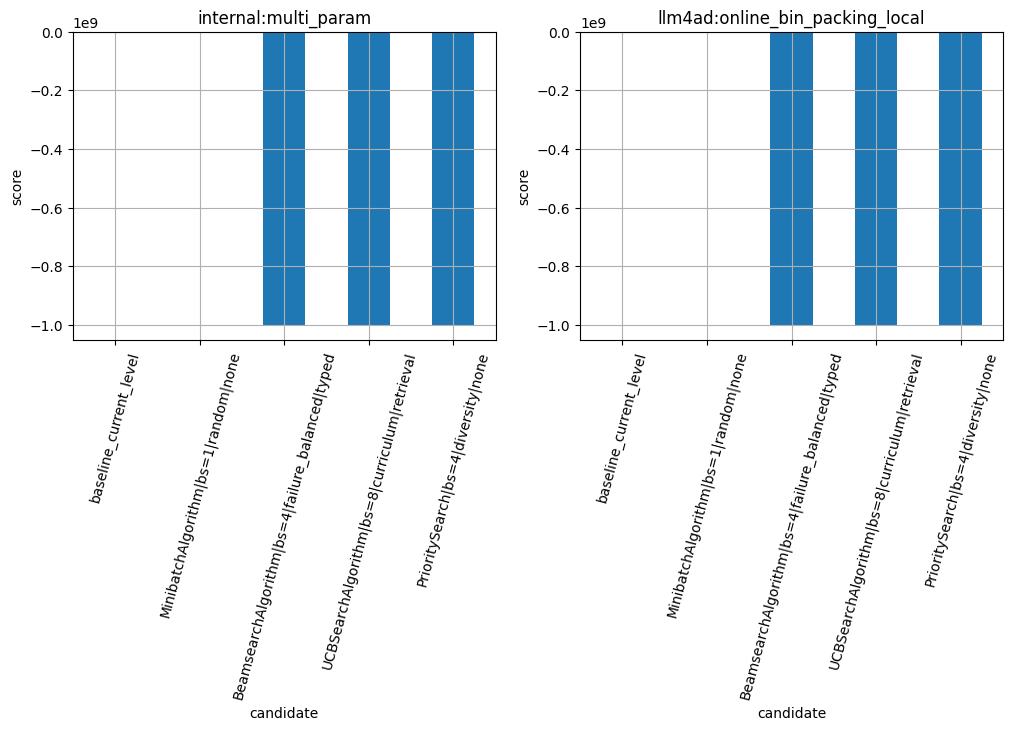

,problem,candidate,score,delta_vs_baseline
0,internal:multi_param,baseline_current_level,-1.0,0.0
1,llm4ad:online_bin_packing_local,baseline_current_level,-2091.8,0.0


Interpretation
- internal:multi_param: no positive delta; this is a negative result worth investigating
- llm4ad:online_bin_packing_local: no positive delta; this is a negative result worth investigating


In [5]:

# Cell 5 — Example A figures + compact interpretation

best_A = (
    df_A.sort_values(["problem", "score"], ascending=[True, False])
        .groupby("problem", as_index=False)
        .first()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, problem in zip(axes, sorted(df_A["problem"].unique())):
    sub = df_A[df_A["problem"] == problem][["candidate", "score"]].copy()
    sub = sub.sort_values("score", ascending=False)
    sub.plot(kind="bar", x="candidate", y="score", ax=ax, legend=False, title=problem)
    ax.set_ylabel("score")
    ax.tick_params(axis='x', labelrotation=75)
plt.tight_layout()
plt.show()

display(best_A[["problem", "candidate", "score", "delta_vs_baseline"]])

print("Interpretation")
for _, row in best_A.iterrows():
    if row["delta_vs_baseline"] > 0:
        print(f"- {row['problem']}: positive evidence that O1 setup search improves over the baseline by {row['delta_vs_baseline']:.3f}")
    else:
        print(f"- {row['problem']}: no positive delta; this is a negative result worth investigating")


## Example B — O2a code-level component improvement

**What it is testing**

- can the system improve the **implementation** of a component, not just select from a menu?
- here:
  - `batch_design`
  - `trace_summarizer`

**Positive claim**
- the code surface can learn better source code than the baseline.

**Negative claim**
- this is still evaluated mainly through deterministic or simplified validators, so it is stronger as a mechanics test than as a broad benchmark claim.

See:
- file: `examples/recursive_opt_example_B_improve_component.py`
- key functions: `improve_component`, `batch_design_baseline`, `batch_design_improved`, `trace_summarizer_baseline`, `trace_summarizer_improved`
- level class: `CodeArtifactLevel`


In [6]:

# Cell 6 — reproduce example B baseline vs improved component scores

rows_B = []

base_score, new_score = exB.improve_component(
    "llm4ad:online_bin_packing_local",
    "batch_design",
    exB.batch_design_baseline,
    exB.batch_design_improved,
    objective=(
        "maximize held-out pass rate by sampling failing/hard items; keep batch "
        + exB.BATCH_DESIGN_GUIDANCE
    ),
)
rows_B.extend([
    {"component": "batch_design", "problem": "llm4ad:online_bin_packing_local", "version": "baseline", "score": base_score},
    {"component": "batch_design", "problem": "llm4ad:online_bin_packing_local", "version": "improved", "score": new_score},
])

base_score, new_score = exB.improve_component(
    "internal:code_param",
    "trace_summarizer",
    exB.trace_summarizer_baseline,
    exB.trace_summarizer_improved,
    objective="preserve error evidence (failing assertion + expected/got), drop INFO/DEBUG, stay concise",
)
rows_B.extend([
    {"component": "trace_summarizer", "problem": "internal:code_param", "version": "baseline", "score": base_score},
    {"component": "trace_summarizer", "problem": "internal:code_param", "version": "improved", "score": new_score},
])

df_B = pd.DataFrame(rows_B)
df_B["delta"] = df_B.groupby(["component", "problem"])["score"].transform(lambda s: s - s.min())
df_B


  [batch_design] baseline score=0.800
           feedback: [batch_design@llm4ad:online_bin_packing_local] validation_pool n=12, k=4; hard/failing indices are [0, 3, 6, 9] (defined by idx % 3 == 0); picked [0, 1, 2, 3]; hard_items=2/4; diversity=1.00. Missing hard indices [6, 9]; pick hard/failing items before easy items.
  [batch_design] improved score=1.000  (Δ=+0.200)
           feedback: [batch_design@llm4ad:online_bin_packing_local] validation_pool n=12, k=4; hard/failing indices are [0, 3, 6, 9] (defined by idx % 3 == 0); picked [0, 3, 6, 9]; hard_items=4/4; diversity=1.00. Good: all validation hard/failing items are selected.
  [trace_summarizer] baseline score=0.823
           feedback: [trace_summarizer@internal:code_param] len=200 (src 282); error_evidence_preserved=2/2; conciseness=0.29. good: keeps the failing assertion.
  [trace_summarizer] improved score=0.959  (Δ=+0.137)
           feedback: [trace_summarizer@internal:code_param] len=46 (src 282); error_evidence_preserved

,component,problem,version,score,delta
0,batch_design,llm4ad:online_bin_packing_local,baseline,0.800000,0.000000
1,batch_design,llm4ad:online_bin_packing_local,improved,1.000000,0.200000
2,trace_summarizer,internal:code_param,baseline,0.822695,0.000000
3,trace_summarizer,internal:code_param,improved,0.959220,0.136525


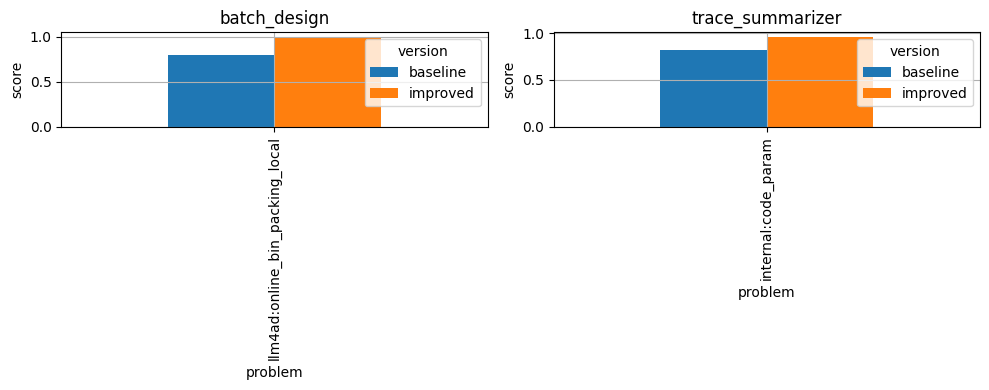

version,component,problem,baseline,improved,delta_improved_minus_baseline
0,batch_design,llm4ad:online_bin_packing_local,0.800000,1.00000,0.200000
1,trace_summarizer,internal:code_param,0.822695,0.95922,0.136525


Interpretation
- batch_design on llm4ad:online_bin_packing_local: improved-baseline = 0.200
- trace_summarizer on internal:code_param: improved-baseline = 0.137


In [7]:

# Cell 7 — Example B figures + interpretation

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, component in zip(axes, ["batch_design", "trace_summarizer"]):
    sub = df_B[df_B["component"] == component]
    pivot = sub.pivot(index="problem", columns="version", values="score")
    pivot.plot(kind="bar", ax=ax, title=component)
    ax.set_ylabel("score")
plt.tight_layout()
plt.show()

summary_B = (
    df_B.pivot_table(index=["component", "problem"], columns="version", values="score")
      .reset_index()
)
summary_B["delta_improved_minus_baseline"] = summary_B["improved"] - summary_B["baseline"]
display(summary_B)

print("Interpretation")
for _, row in summary_B.iterrows():
    print(f"- {row['component']} on {row['problem']}: improved-baseline = {row['delta_improved_minus_baseline']:.3f}")


## Example C — capability learning under multiple objectives

**What it is testing**

- learn a new capability artifact from a specification
- trade off:
  - `accuracy` (maximize)
  - `cost` (minimize)

**Positive claim**
- recursive optimization is useful even when there is no single scalar objective and when the artifact is a reusable “skill/procedure”-like text.

**Negative claim**
- capability learning still depends heavily on the evaluator design and the objective scalarization / Pareto procedure.

See:
- file: `examples/recursive_opt_example_C_learn_capability.py`
- key functions/classes: `CapabilityArtifact`, `learn_capability`, `make_multiobjective_evaluator`


In [8]:

# Cell 8 — reproduce example C candidate frontier (offline)

evaluator_C = make_multiobjective_evaluator(
    exC.PROBLEMS,
    exC.OBJECTIVES,
    required_terms=("plan", "verify"),
)

rows_C = []
for impl in exC.CANDIDATE_IMPLS:
    art = exC.CapabilityArtifact(seed_impl=impl, evaluator=evaluator_C, memory=None)
    agg = {"accuracy": 0.0, "cost": 0.0}
    for p in exC.PROBLEMS:
        out = art.forward(p)
        objs = out.data["objectives"] if hasattr(out, "data") else out["objectives"]
        for k in agg:
            agg[k] += objs[k] / len(exC.PROBLEMS)
    rows_C.append({
        "impl": impl,
        "accuracy": agg["accuracy"],
        "cost": agg["cost"],
        "short_label": impl[:48] + ("..." if len(impl) > 48 else "")
    })

df_C = pd.DataFrame(rows_C)
df_C


/home/xav/miniconda3/envs/humanllm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,impl,accuracy,cost,short_label
0,Answer directly.,1.0,0.026667,Answer directly.
1,"Make a short plan, then answer.",1.0,0.051667,"Make a short plan, then answer."
2,Make a short plan; execute; then VERIFY/CHECK ...,1.0,0.185000,Make a short plan; execute; then VERIFY/CHECK ...
3,Write an extremely detailed multi-paragraph ch...,1.0,0.185000,Write an extremely detailed multi-paragraph ch...


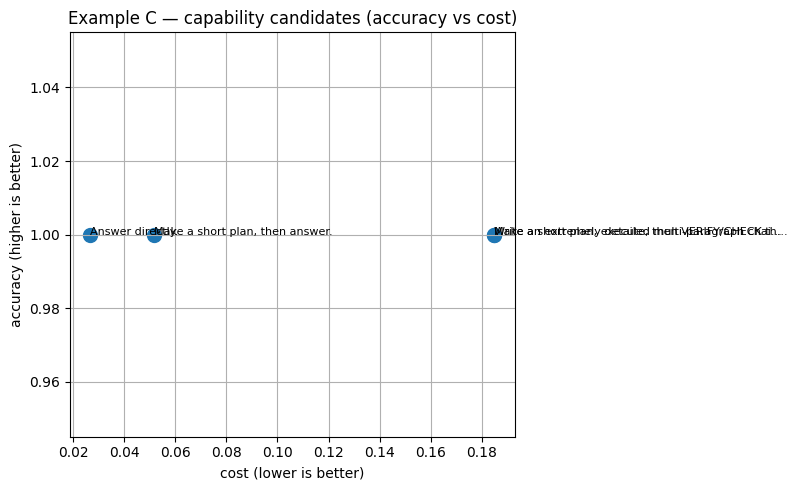

Best accuracy candidate:


,short_label,accuracy,cost
0,Answer directly.,1.0,0.026667


Cheapest candidate:


,short_label,accuracy,cost
0,Answer directly.,1.0,0.026667


Balanced candidate (accuracy - 0.5*cost):


,short_label,accuracy,cost,score
0,Answer directly.,1.0,0.026667,0.986667


Interpretation
- Positive: the branch can express a genuine multiobjective tradeoff.
- Negative: what is 'best' depends on the selection rule, not only on raw outputs.


In [9]:

# Cell 9 — Example C figures + interpretation

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_C["cost"], df_C["accuracy"], s=100)
for _, row in df_C.iterrows():
    ax.annotate(row["short_label"], (row["cost"], row["accuracy"]), fontsize=8)
ax.set_xlabel("cost (lower is better)")
ax.set_ylabel("accuracy (higher is better)")
ax.set_title("Example C — capability candidates (accuracy vs cost)")
plt.tight_layout()
plt.show()

best_acc = df_C.sort_values("accuracy", ascending=False).iloc[0]
best_cost = df_C.sort_values("cost", ascending=True).iloc[0]
balanced = df_C.assign(score=df_C["accuracy"] - 0.5 * df_C["cost"]).sort_values("score", ascending=False).iloc[0]

print("Best accuracy candidate:")
display(best_acc.to_frame().T[["short_label", "accuracy", "cost"]])
print("Cheapest candidate:")
display(best_cost.to_frame().T[["short_label", "accuracy", "cost"]])
print("Balanced candidate (accuracy - 0.5*cost):")
display(balanced.to_frame().T[["short_label", "accuracy", "cost", "score"]])

print("Interpretation")
print("- Positive: the branch can express a genuine multiobjective tradeoff.")
print("- Negative: what is 'best' depends on the selection rule, not only on raw outputs.")


## Example D — O2 family policy learning and O3 prior induction

**What it is testing**

- **O2:** can one trainable family policy produce better setup choices per family?
- **O3:** can one shared prior transfer to a held-out family?

**Positive claim**
- the branch now has explicit trainable O2 and O3 levels, instead of only manual loops.

**Negative claim**
- held-out transfer can still fail; this is the important “no universal default” negative result rather than a bug.

See:
- file: `examples/recursive_opt_example_D_cross_family.py`
- key objects: `FamilyPolicyLevel`, `PriorInductionLevel`
- memory / lineage: `MemoryLite.record_artifact`, `artifact_history`, `best_artifact`


In [10]:

# Cell 10 — reproduce example D candidate scores

run_task_D = make_scored_task_runner(exD.SCORING)
rows_D_policy = []
rows_D_prior = []

mem_D = MemoryLite(root=str(REPO_ROOT / "mem_D_collect"))

# O2 policy candidates
o2 = FamilyPolicyLevel(exD.FAMILIES, run_task=run_task_D, memory=mem_D)
for pol in exD.POLICY_CANDIDATES:
    o2.propose(pol)
    out = o2.forward()
    s, _ = call_guide(None, out)
    per_family = out.data["per_family"]
    rows_D_policy.append({
        "policy": pol,
        "score": s,
        **{f"family::{k}": v for k, v in per_family.items()}
    })

# O3 prior candidates
train_f = {"optimization_control": exD.FAMILIES["optimization_control"]}
holdout_f = {"reasoning_control": exD.FAMILIES["reasoning_control"]}
o3 = PriorInductionLevel(train_f, holdout_f, run_task=run_task_D, memory=mem_D)
for cand in exD.PRIOR_CANDIDATES:
    o3.propose(**cand)
    out = o3.forward()
    rows_D_prior.append({
        "prior": json.dumps(cand, sort_keys=True),
        "heldout_transfer": out.data["score"],
        **{f"family::{k}": v for k, v in out.data["per_family"].items()}
    })

df_D_policy = pd.DataFrame(rows_D_policy)
df_D_prior = pd.DataFrame(rows_D_prior)
df_D_policy, df_D_prior


Evaluating agent (iteration 0):   0%|          | 0/1 [00:00<?, ?it/s]

Evaluating agent (iteration 0): 100%|██████████| 1/1 [00:00<00:00,  1.27it/s]

Evaluating agent (iteration 0): 100%|██████████| 1/1 [00:00<00:00,  1.27it/s]

[Step 0] Average test score: -2091.8


Evaluating agent (iteration 0):   0%|          | 0/1 [00:00<?, ?it/s]

...

[Step 0] Average test score: -1.0


Evaluating agent (iteration 0):   0%|          | 0/1 [00:00<?, ?it/s]

Evaluating agent (iteration 0): 100%|██████████| 1/1 [00:00<00:00, 3432.33it/s]

[Step 0] Average test score: -3.0


(                                              policy  score  \
 0  optimization_control => batch_design=random, m...    0.0   
 1  optimization_control => batch_design=failure_b...    0.0   
 
    family::optimization_control  family::reasoning_control  
 0                           0.0                        0.0  
 1                           0.0                        0.0  ,
                                                prior  heldout_transfer  \
 0  {"batch_design": "failure_balanced", "memory_p...               0.0   
 1  {"batch_design": "curriculum", "memory_policy"...               0.0   
 
    family::reasoning_control  
 0                        0.0  
 1                        0.0  )

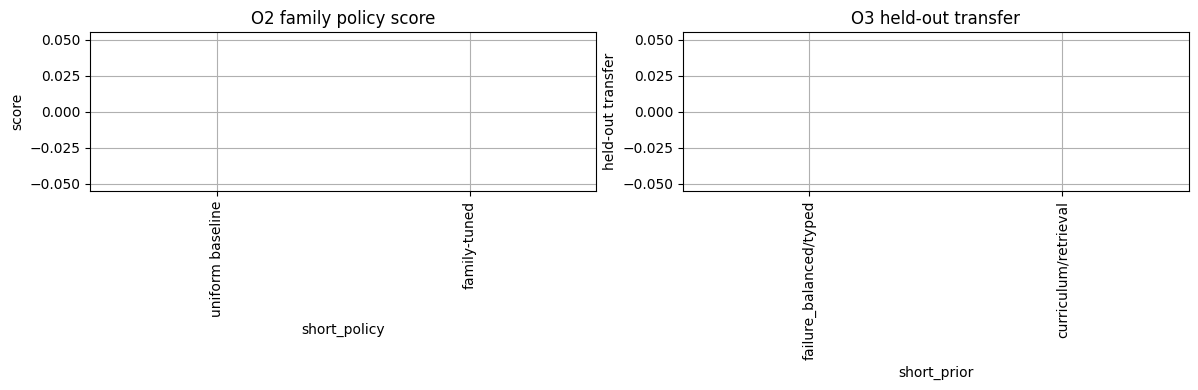

,score,family::optimization_control,family::reasoning_control
0,0.0,0.0,0.0
1,0.0,0.0,0.0


,heldout_transfer,family::reasoning_control
0,0.0,0.0
1,0.0,0.0


Interpretation
- Positive: O2 can learn different setup choices per family.
- Negative: O3 may show poor transfer, which is precisely the 'no universal default' result.


In [11]:

# Cell 11 — Example D figures + interpretation

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# O2 policy scores
df_D_policy_plot = df_D_policy.copy()
df_D_policy_plot["short_policy"] = [
    "uniform baseline" if i == 0 else "family-tuned"
    for i in range(len(df_D_policy_plot))
]
df_D_policy_plot.plot(kind="bar", x="short_policy", y="score", ax=axes[0], legend=False, title="O2 family policy score")
axes[0].set_ylabel("score")

# O3 transfer
df_D_prior_plot = df_D_prior.copy()
df_D_prior_plot["short_prior"] = [
    "failure_balanced/typed" if i == 0 else "curriculum/retrieval"
    for i in range(len(df_D_prior_plot))
]
df_D_prior_plot.plot(kind="bar", x="short_prior", y="heldout_transfer", ax=axes[1], legend=False, title="O3 held-out transfer")
axes[1].set_ylabel("held-out transfer")

plt.tight_layout()
plt.show()

display(df_D_policy[["score", "family::optimization_control", "family::reasoning_control"]])
display(df_D_prior[["heldout_transfer", "family::reasoning_control"]])

print("Interpretation")
print("- Positive: O2 can learn different setup choices per family.")
print("- Negative: O3 may show poor transfer, which is precisely the 'no universal default' result.")


## Cross-level summary: what currently works, what is still limited

This is the cell to cite in discussions when someone asks:
- “What has the branch *actually* demonstrated?”
- “What is evidence vs aspiration?”


In [12]:

# Cell 12 — summary table for O0/O1/O2/O3

summary_rows = [
    {
        "level": "O0",
        "claim": "Task artifact / capability can be optimized",
        "evidence": "Example C capability frontier; artifact/code surfaces exist",
        "positive": "yes",
        "limitation": "artifact priors are still lighter than config priors",
    },
    {
        "level": "O1",
        "claim": "Best setup can be learned per problem/family",
        "evidence": "Example A candidate scores by problem",
        "positive": "yes",
        "limitation": "mostly selection/config, not new implementation invention",
    },
    {
        "level": "O2",
        "claim": "Components and family policies can be improved",
        "evidence": "Example B component deltas + Example D O2 policy scores",
        "positive": "yes",
        "limitation": "code-surface proof is strongest on bounded/deterministic evaluators",
    },
    {
        "level": "O3",
        "claim": "Transferable priors can be induced and tested on held-out families",
        "evidence": "Example D held-out transfer",
        "positive": "partially",
        "limitation": "transfer can fail; current breadth of family coverage is still small",
    },
    {
        "level": "O_n",
        "claim": "Recursive control plane can be specified declaratively",
        "evidence": "spec.py / run_spec / budgets / prior reuse",
        "positive": "yes structurally",
        "limitation": "spec itself is not yet searched as a first-class experiment object",
    },
]
df_summary = pd.DataFrame(summary_rows)
display(df_summary)


,level,claim,evidence,positive,limitation
0,O0,Task artifact / capability can be optimized,Example C capability frontier; artifact/code s...,yes,artifact priors are still lighter than config ...
1,O1,Best setup can be learned per problem/family,Example A candidate scores by problem,yes,"mostly selection/config, not new implementatio..."
2,O2,Components and family policies can be improved,Example B component deltas + Example D O2 poli...,yes,code-surface proof is strongest on bounded/det...
3,O3,Transferable priors can be induced and tested ...,Example D held-out transfer,partially,transfer can fail; current breadth of family c...
4,O_n,Recursive control plane can be specified decla...,spec.py / run_spec / budgets / prior reuse,yes structurally,spec itself is not yet searched as a first-cla...


## Practical recommendation — next best experiments

The next recommended matrix should **not** try to prove everything at once.

Best next pack:

1. **HF QA / reasoning family**
   - `hf:hotpot_qa`
   - 2–4 `hf:bbeh/*` tasks discovered dynamically

2. **Internal multiobjective family**
   - `internal:multiobjective_bbeh`
   - `internal:multiobjective_gsm8k`

3. **One non-QA family for transfer realism**
   - one `llm4ad:*` family

This combination is the most informative because:
- HF QA is best for O0/O1/O2 setup and family-policy stress,
- internal multiobjective tasks stress capability tradeoffs,
- one non-QA family checks whether learned priors really transfer beyond textual QA.


In [13]:

# Cell 13 — discover available HF tasks (best effort) and build recommended family packs

def list_trace_bench_tasks():
    try:
        out = subprocess.run(
            ["trace-bench", "list-tasks"],
            capture_output=True, text=True, cwd=str(REPO_ROOT)
        )
        if out.returncode == 0:
            return [ln.strip() for ln in out.stdout.splitlines() if ":" in ln]
    except Exception:
        pass
    return []

all_tasks = list_trace_bench_tasks()

hf_hotpot = [t for t in all_tasks if t.startswith("hf:hotpot_qa")]
hf_bbeh = [t for t in all_tasks if t.startswith("hf:bbeh/")]
internal_mo = [t for t in all_tasks if t.startswith("internal:multiobjective_")]
llm4ad_any = [t for t in all_tasks if t.startswith("llm4ad:")]

recommended_pack = {
    "qa_reasoning": (hf_hotpot[:1] or ["hf:hotpot_qa"]) + (hf_bbeh[:2] or ["hf:bbeh/object_counting", "hf:bbeh/word_sorting"]),
    "internal_tradeoff": internal_mo[:2] or ["internal:multiobjective_bbeh", "internal:multiobjective_gsm8k"],
    "non_qa_transfer": llm4ad_any[:1] or ["llm4ad:online_bin_packing_local"],
}

recommended_pack


{'qa_reasoning': ['hf:hotpot_qa',
  'hf:bbeh/object_counting',
  'hf:bbeh/word_sorting'],
 'internal_tradeoff': ['internal:multiobjective_bbeh',
  'internal:multiobjective_gsm8k'],
 'non_qa_transfer': ['llm4ad:online_bin_packing_local']}

In [14]:

# Cell 14 — recommended recursive specs (O1, O2, O3) for the next phase

spec_o1_hf = {
    "families": {"qa_reasoning": recommended_pack["qa_reasoning"]},
    "reuse_priors": True,
    "levels": [
        {
            "id": "o1_setup_hf",
            "surface": "config",
            "family": "qa_reasoning",
            "fixed": {
                "trace_type": "internal",
                "optimizer": "OptoPrime",
                "guide": "LLMJudge",
            },
            "targets": ["batch_size", "batch_design", "memory_policy", "trainer"],
            "iterations": 3,
        }
    ],
}

spec_o2_hf = {
    "families": {
        "qa_reasoning": recommended_pack["qa_reasoning"],
        "internal_tradeoff": recommended_pack["internal_tradeoff"],
    },
    "reuse_priors": True,
    "levels": [
        {
            "id": "o2_family_policy",
            "surface": "family_policy",
            "families": ["qa_reasoning", "internal_tradeoff"],
            "targets": ["batch_design", "memory_policy", "trainer", "trace_type"],
            "iterations": 2,
        }
    ],
}

spec_o3_cross = {
    "families": {
        "qa_reasoning": recommended_pack["qa_reasoning"],
        "internal_tradeoff": recommended_pack["internal_tradeoff"],
        "non_qa_transfer": recommended_pack["non_qa_transfer"],
    },
    "reuse_priors": True,
    "levels": [
        {
            "id": "o3_transfer_prior",
            "surface": "prior",
            "families": ["qa_reasoning", "internal_tradeoff", "non_qa_transfer"],
            "targets": ["batch_design", "memory_policy", "trainer", "trace_type"],
            "iterations": 2,
        }
    ],
}

display(spec_o1_hf)
display(spec_o2_hf)
display(spec_o3_cross)


{'families': {'qa_reasoning': ['hf:hotpot_qa',
   'hf:bbeh/object_counting',
   'hf:bbeh/word_sorting']},
 'reuse_priors': True,
 'levels': [{'id': 'o1_setup_hf',
   'surface': 'config',
   'family': 'qa_reasoning',
   'fixed': {'trace_type': 'internal',
    'optimizer': 'OptoPrime',
    'guide': 'LLMJudge'},
   'targets': ['batch_size', 'batch_design', 'memory_policy', 'trainer'],
   'iterations': 3}]}

{'families': {'qa_reasoning': ['hf:hotpot_qa',
   'hf:bbeh/object_counting',
   'hf:bbeh/word_sorting'],
  'internal_tradeoff': ['internal:multiobjective_bbeh',
   'internal:multiobjective_gsm8k']},
 'reuse_priors': True,
 'levels': [{'id': 'o2_family_policy',
   'surface': 'family_policy',
   'families': ['qa_reasoning', 'internal_tradeoff'],
   'targets': ['batch_design', 'memory_policy', 'trainer', 'trace_type'],
   'iterations': 2}]}

{'families': {'qa_reasoning': ['hf:hotpot_qa',
   'hf:bbeh/object_counting',
   'hf:bbeh/word_sorting'],
  'internal_tradeoff': ['internal:multiobjective_bbeh',
   'internal:multiobjective_gsm8k'],
  'non_qa_transfer': ['llm4ad:online_bin_packing_local']},
 'reuse_priors': True,
 'levels': [{'id': 'o3_transfer_prior',
   'surface': 'prior',
   'families': ['qa_reasoning', 'internal_tradeoff', 'non_qa_transfer'],
   'targets': ['batch_design', 'memory_policy', 'trainer', 'trace_type'],
   'iterations': 2}]}

In [15]:

# Cell 15 — optional execution template for the recommended experiments
# Toggle RUN_RECOMMENDED = True once the branch + Trace-Bench environment is ready.

RUN_RECOMMENDED = False

if RUN_RECOMMENDED:
    out_o1 = run_spec(spec_o1_hf)
    out_o2 = run_spec(spec_o2_hf)
    out_o3 = run_spec(spec_o3_cross)

    display(out_o1["results"])
    display(out_o2["results"])
    display(out_o3["results"])
else:
    print("RUN_RECOMMENDED=False — spec dictionaries are ready to run when desired.")


RUN_RECOMMENDED=False — spec dictionaries are ready to run when desired.


## Appendix — cell → code map for colleagues

| Cells | Purpose | Main files / functions to inspect | What to tweak first |
|---|---|---|---|
| 1–3 | setup, imports, adapter registration, helpers | `tracebench.py`, `memory.py`, `runmode.py` | repo root, installed extras, reuse of existing memories |
| 4–5 | O1 setup search figures | `recursive_opt_example_A_learn_setup.py`, `MetaLevel`, `LevelConfig` | candidate configs, chosen trainable fields |
| 6–7 | O2a code improvement figures | `recursive_opt_example_B_improve_component.py`, `CodeArtifactLevel`, `ComponentSpec` | baseline/improved component pair, evaluator |
| 8–9 | O0/O1 capability frontier | `recursive_opt_example_C_learn_capability.py`, `CapabilityArtifact`, `make_multiobjective_evaluator` | objectives, required terms, scalarization |
| 10–11 | O2/O3 family transfer figures | `recursive_opt_example_D_cross_family.py`, `FamilyPolicyLevel`, `PriorInductionLevel` | family definitions, scoring config, tracebench bounds |
| 12 | one-line evidence summary | all examples + `levels.py` | use this as the branch evidence checkpoint |
| 13–15 | next practical experiments | `spec.py`, `run_spec`, Trace-Bench task discovery | family pack, reuse_priors, iterations, targets |

Recommended first tweaks:
1. change the family packs in Cell 13,
2. change `targets` in Cell 14,
3. increase `iterations` slowly,
4. only then introduce broader O3 sweeps.
